# 11 Should-Move Classifier

Trains a classifier to predict whether a place's pin should be moved, using
only features available from the LLM annotation pipeline — no ground truth
coordinates used as inputs.

**Why this matters:** in production you can't compute offset_haversine_m
without running the full GT pipeline. This classifier lets you flag high-risk
places for review using only the annotation metadata (confidence, entry mode,
tier, complexity, ambiguity).

Three models compared: Logistic Regression, Decision Tree, Random Forest.

## Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
PROCESSED = PROJECT_ROOT / "data" / "processed"

gt = pd.read_csv(PROCESSED / "ground_truth_combined.csv")
print(f"Loaded {len(gt)} rows")
print(f"should_move=True:  {gt['should_move'].sum()} ({gt['should_move'].mean()*100:.1f}%)")
print(f"should_move=False: {(~gt['should_move']).sum()} ({(~gt['should_move']).mean()*100:.1f}%)")


Loaded 3425 rows
should_move=True:  392 (11.4%)
should_move=False: 3033 (88.6%)


## Feature engineering

Features used — all available from the LLM annotation pipeline without GT coordinates:

| Feature | Source | Rationale |
|---|---|---|
| `gt_confidence` | LLM output | Lower confidence → more likely to need a move |
| `tier_label` | Rule-based | Open space / no-building behave very differently |
| `place_complexity` | Rule-based | Complex places have harder pin placement |
| `pin_ambiguity` | Rule-based | High ambiguity → more likely wrong |
| `entry_mode` | LLM output | 'both' means LLM found distinct car+ped entries |
| `sub_tier_label` | Rule-based | More granular than tier |


In [2]:
df = gt.copy()

# Label encode categoricals
cat_features = ["tier_label", "place_complexity", "pin_ambiguity",
                "entry_mode", "sub_tier_label"]

encoders = {}
for col in cat_features:
    df[col] = df[col].fillna("unknown")
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    encoders[col] = le

FEATURES = ["gt_confidence"] + [c + "_enc" for c in cat_features]
TARGET   = "should_move"

X = df[FEATURES].fillna(0)
y = df[TARGET].astype(int)

print("Features:", FEATURES)
print("Class balance:", y.value_counts().to_dict())
print("\nFeature summary:")
print(X.describe().round(3).to_string())


Features: ['gt_confidence', 'tier_label_enc', 'place_complexity_enc', 'pin_ambiguity_enc', 'entry_mode_enc', 'sub_tier_label_enc']
Class balance: {0: 3033, 1: 392}

Feature summary:
       gt_confidence  tier_label_enc  place_complexity_enc  pin_ambiguity_enc  entry_mode_enc  sub_tier_label_enc
count       3425.000        3425.000              3425.000           3425.000        3425.000            3425.000
mean           0.821           2.361                 1.787              0.796           1.193               5.209
std            0.288           0.976                 0.587              0.597           1.271               1.958
min            0.000           0.000                 0.000              0.000           0.000               0.000
25%            0.800           1.000                 2.000              0.000           0.000               3.000
50%            1.000           3.000                 2.000              1.000           0.000               6.000
75%            1.000

## Train / test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} rows  ({y_train.sum()} positive)")
print(f"Test:  {len(X_test)} rows  ({y_test.sum()} positive)")


Train: 2740 rows  (314 positive)
Test:  685 rows  (78 positive)


## Model 1: Logistic Regression

In [4]:
lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=500, random_state=42))])
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["stay","move"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

        stay       0.89      1.00      0.94       607
        move       0.00      0.00      0.00        78

    accuracy                           0.88       685
   macro avg       0.44      0.50      0.47       685
weighted avg       0.78      0.88      0.83       685

ROC-AUC: 0.857


## Model 2: Decision Tree

In [5]:
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("=== Decision Tree (depth=4) ===")
print(classification_report(y_test, y_pred_dt, target_names=["stay","move"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.3f}")


=== Decision Tree (depth=4) ===
              precision    recall  f1-score   support

        stay       0.99      0.99      0.99       607
        move       0.88      0.88      0.88        78

    accuracy                           0.97       685
   macro avg       0.93      0.93      0.93       685
weighted avg       0.97      0.97      0.97       685

ROC-AUC: 0.994


## Model 3: Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=10,
                             random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["stay","move"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")


=== Random Forest ===
              precision    recall  f1-score   support

        stay       1.00      0.94      0.97       607
        move       0.68      0.99      0.80        78

    accuracy                           0.94       685
   macro avg       0.84      0.96      0.88       685
weighted avg       0.96      0.94      0.95       685

ROC-AUC: 0.994


## Cross-validation comparison

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in [("LogReg", lr), ("DecTree", dt), ("RandForest", rf)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    results[name] = scores
    print(f"{name:12}  AUC: {scores.mean():.3f} ± {scores.std():.3f}")


LogReg        AUC: 0.847 ± 0.014
DecTree       AUC: 0.993 ± 0.002


RandForest    AUC: 0.993 ± 0.001


## Feature importance (Random Forest)

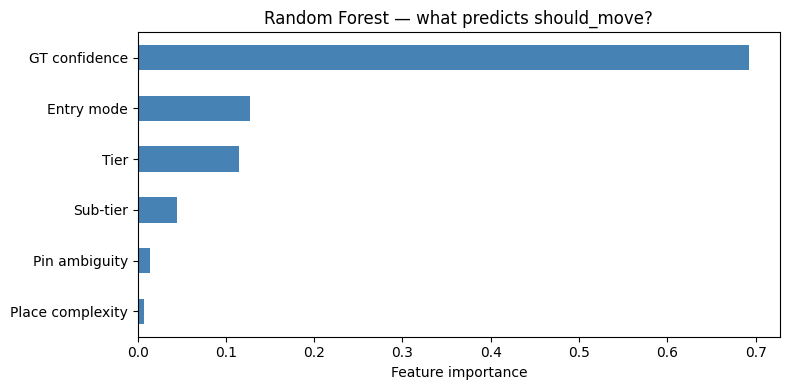

GT confidence       0.693
Entry mode          0.128
Tier                0.114
Sub-tier            0.044
Pin ambiguity       0.014
Place complexity    0.007


In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

# Clean up names for display
name_map = {
    "gt_confidence": "GT confidence",
    "tier_label_enc": "Tier",
    "place_complexity_enc": "Place complexity",
    "pin_ambiguity_enc": "Pin ambiguity",
    "entry_mode_enc": "Entry mode",
    "sub_tier_label_enc": "Sub-tier",
}
importances.index = [name_map.get(i, i) for i in importances.index]

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest — what predicts should_move?")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PROCESSED / "classifier" / "classifier_feature_importance.png", dpi=150)
plt.show()

print(importances.round(3).to_string())


## Decision tree visualisation

Shows the actual rules the tree learned — readable logic for why a pin should move.

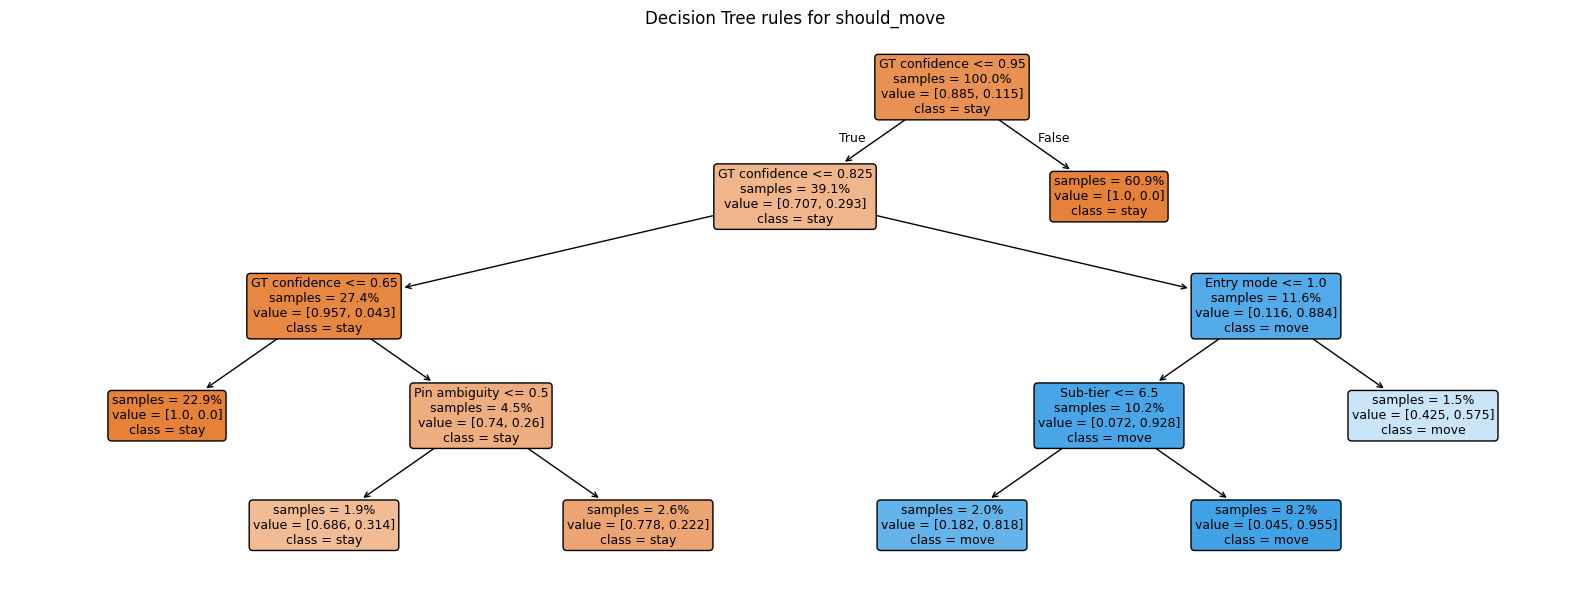

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(dt, feature_names=[name_map.get(f,f) for f in FEATURES],
          class_names=["stay","move"], filled=True, rounded=True,
          fontsize=9, ax=ax, impurity=False, proportion=True)
plt.title("Decision Tree rules for should_move", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED / "classifier" / "classifier_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()


## Confusion matrices

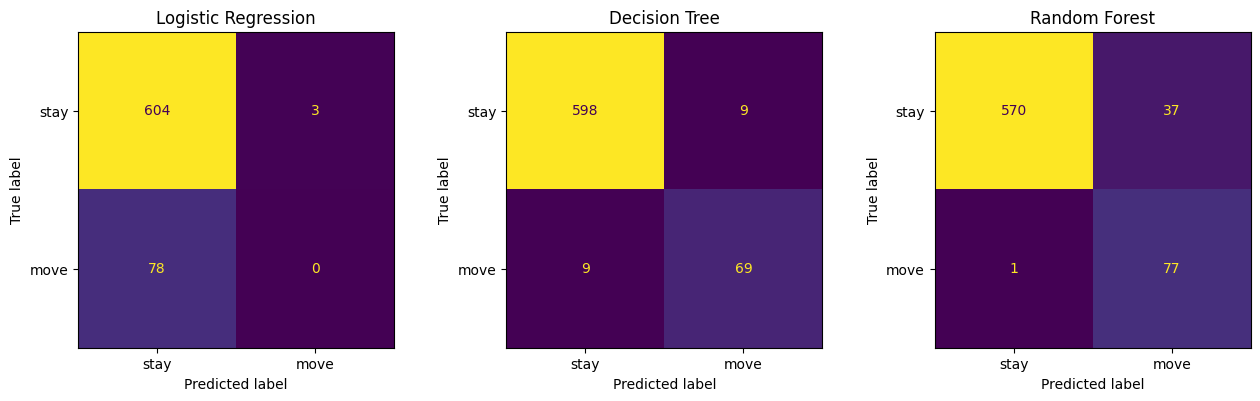

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree",       y_pred_dt),
    ("Random Forest",       y_pred_rf),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["stay","move"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(PROCESSED / "classifier" / "classifier_confusion_matrices.png", dpi=150)
plt.show()


## ROC curves

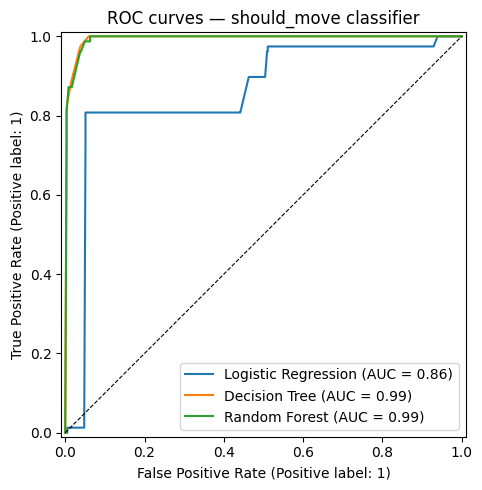

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, y_prob in [("Logistic Regression", y_prob_lr),
                     ("Decision Tree",        y_prob_dt),
                     ("Random Forest",        y_prob_rf)]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0,1],[0,1],"k--", linewidth=0.8)
ax.set_title("ROC curves — should_move classifier")
plt.tight_layout()
plt.savefig(PROCESSED / "classifier" / "classifier_roc_curves.png", dpi=150)
plt.show()


## Apply best model to full dataset

In [12]:
# Apply random forest to score all 3,425 places
df["move_probability"] = rf.predict_proba(X)[:,1]
df["move_predicted"]   = rf.predict(X)

# Top places the model thinks should move (that aren't already flagged)
high_risk = df[df["move_probability"] > 0.5].sort_values("move_probability", ascending=False)
print(f"Places with move_probability > 0.5:  {len(high_risk)}")
print(f"  Already flagged should_move=True:  {high_risk['should_move'].sum()}")
print(f"  Not yet flagged (new discoveries): {(~high_risk['should_move']).sum()}")
print()
print("Top 15 highest-risk places not yet flagged:")
new_finds = high_risk[~high_risk["should_move"]].head(15)
print(new_finds[["name","category_primary","tier_label","gt_confidence",
                  "entry_mode","move_probability"]].to_string())


Places with move_probability > 0.5:  564
  Already flagged should_move=True:  391
  Not yet flagged (new discoveries): 173

Top 15 highest-risk places not yet flagged:
                                name          category_primary           tier_label  gt_confidence entry_mode  move_probability
1776                          Subway             sandwich_shop  standard_commercial            0.9       both          0.979232
1496                   Champs Sports            sporting_goods  standard_commercial            0.9       both          0.979232
1602                   The Yarn Shop           arts_and_crafts  standard_commercial            0.9       both          0.979232
1600                   Marco's Pizza          pizza_restaurant  standard_commercial            0.9       both          0.979232
2768                     Hobby Lobby           arts_and_crafts  standard_commercial            0.9       both          0.979232
3068        Precision Powder Coating    powder_coating_service  

In [13]:
# Save scored dataset
out_cols = list(gt.columns) + ["move_probability", "move_predicted"]
out = df[[c for c in out_cols if c in df.columns]]
out.to_csv(PROCESSED / "classifier" / "should_move_scored.csv", index=False)

# Summary
lines = [
    "Should-Move Classifier Summary",
    "",
    "Features used (no GT coordinate leakage):",
    "  gt_confidence, tier_label, place_complexity, pin_ambiguity, entry_mode, sub_tier_label",
    "",
    "5-fold cross-validated ROC-AUC:",
]
for name, scores in results.items():
    lines.append(f"  {name:12}  {scores.mean():.3f} ± {scores.std():.3f}")
lines += [
    "",
    f"Random Forest on test set:",
    classification_report(y_test, y_pred_rf, target_names=["stay","move"]),
]
(PROCESSED / "classifier" / "classifier_summary.txt").write_text("\n".join(lines)+"\n")
print("Saved: should_move_scored.csv")
print("Saved: classifier_summary.txt")


Saved: should_move_scored.csv
Saved: classifier_summary.txt
